## Part 1: Installing Packages

In [18]:

import sys
!{sys.executable} -m pip install statsmodels


   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.6 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.6 MB 965.9 kB/s eta 0:00:10
   -- ------------------------------------- 0.5/9.6 MB 965.9 kB/s eta 0:00:10
   --- ------------------------------------ 0.8/9.6 MB 935.9 kB/s eta 0:00:10
   ---- ----------------------------------- 1.0/9.6 MB 931.8 kB/s eta 0:00:10
   ----- ---------------------------------- 1.3/9.6 MB 941.1 kB/s eta 0:00:09
   ----- ---------------------------------- 1.3/9.6 MB 941.1 kB/s eta 0:00:09
   ------ --------------------------------- 1.6/9.6 MB 881.5 kB/s eta 0:00:10
   ------- -------------------------------- 1.8/9.6 MB 928.1 kB/s eta 0:00:09
   ------- --------------------


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [19]:

import sys
!{sys.executable} -m pip install scikit-learn xgboost seaborn



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
#Fo data handling libs
import numpy as np
import pandas as pd

#sklearn libs
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn import model_selection
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, ConfusionMatrixDisplay, classification_report
from sklearn.impute import SimpleImputer # For completing/replacing missing values
import matplotlib.pyplot as plt
import math
#For Data Visualisation
import matplotlib.pyplot as plt
import math
import seaborn as sns
sns.set()



# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

## Part 2: Data Preprocessing

In [2]:
data = pd.read_csv("trans.csv")
#view first 5 and last 5
data


,transaction_id,account_id,transaction_timestamp,transaction_amount,currency,transaction_type,channel,origin_city,destination_country,customer_risk_rating,pep_flag,sanctions_flag,alert_generated_flag,sar_filed_flag,customer_type,Sector
0,TX100000000,5766446.0,18/10/2025 21:17,51091.28,USD,Cash Withdrawal,Mobile App,Gweru,ZW,High,1,1,0,1,Corporate,4
1,TX100000001,251240.0,28/7/2025 15:21,124159.06,USD,POS,Internet Banking,Gweru,ZW,High,0,0,0,0,Corporate,4
2,TX100000002,598902.0,20/10/2025 08:38,62749.52,USD,Transfer,Agent,Harare,ZW,High,0,0,0,0,Corporate,3
3,TX100000003,269723.0,30/11/2025 05:23,119556.76,USD,POS,Agent,Gweru,ZW,Low,1,1,1,1,Corporate,6
4,TX100000004,576893.0,1/9/2024 00:03,25909.96,USD,Transfer,Internet Banking,Mutare,ZW,High,0,0,0,0,Corporate,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
152283,TX100152284,83378.0,3/4/2024 05:28,NaN,USD,POS,Internet Banking,Kadoma,ZW,Low,0,0,0,0,Corporate,0
152284,TX100152285,113353.0,26/8/2024 16:55,NaN,USD,Transfer,ATM,Harare,ZW,Low,1,1,1,1,Individual,6
152285,TX100152286,96174.0,21/1/2024 15:37,NaN,USD,Transfer,ATM,Harare,ZW,High,0,0,0,0,Corporate,2
152286,TX100152287,53776.0,21/6/2025 10:43,NaN,USD,Mobile,Mobile App,Bulawayo,ZW,Low,0,0,0,0,Corporate,3


### Exploring Data

In [3]:
data.shape

(152288, 16)

In [4]:
data.head()

,transaction_id,account_id,transaction_timestamp,transaction_amount,currency,transaction_type,channel,origin_city,destination_country,customer_risk_rating,pep_flag,sanctions_flag,alert_generated_flag,sar_filed_flag,customer_type,Sector
0,TX100000000,5766446.0,18/10/2025 21:17,51091.28,USD,Cash Withdrawal,Mobile App,Gweru,ZW,High,1,1,0,1,Corporate,4
1,TX100000001,251240.0,28/7/2025 15:21,124159.06,USD,POS,Internet Banking,Gweru,ZW,High,0,0,0,0,Corporate,4
2,TX100000002,598902.0,20/10/2025 08:38,62749.52,USD,Transfer,Agent,Harare,ZW,High,0,0,0,0,Corporate,3
3,TX100000003,269723.0,30/11/2025 05:23,119556.76,USD,POS,Agent,Gweru,ZW,Low,1,1,1,1,Corporate,6
4,TX100000004,576893.0,1/9/2024 00:03,25909.96,USD,Transfer,Internet Banking,Mutare,ZW,High,0,0,0,0,Corporate,1


In [5]:
data.tail()

,transaction_id,account_id,transaction_timestamp,transaction_amount,currency,transaction_type,channel,origin_city,destination_country,customer_risk_rating,pep_flag,sanctions_flag,alert_generated_flag,sar_filed_flag,customer_type,Sector
152283,TX100152284,83378.0,3/4/2024 05:28,NaN,USD,POS,Internet Banking,Kadoma,ZW,Low,0,0,0,0,Corporate,0
152284,TX100152285,113353.0,26/8/2024 16:55,NaN,USD,Transfer,ATM,Harare,ZW,Low,1,1,1,1,Individual,6
152285,TX100152286,96174.0,21/1/2024 15:37,NaN,USD,Transfer,ATM,Harare,ZW,High,0,0,0,0,Corporate,2
152286,TX100152287,53776.0,21/6/2025 10:43,NaN,USD,Mobile,Mobile App,Bulawayo,ZW,Low,0,0,0,0,Corporate,3
152287,TX100152288,55250.0,30/10/2025 10:09,NaN,USD,Transfer,Mobile App,Bulawayo,ZW,High,0,0,0,0,Corporate,0


In [6]:
data.columns.values

<ArrowStringArray>
[       'transaction_id',            'account_id', 'transaction_timestamp',
    'transaction_amount',              'currency',      'transaction_type',
               'channel',           'origin_city',   'destination_country',
  'customer_risk_rating',              'pep_flag',        'sanctions_flag',
  'alert_generated_flag',        'sar_filed_flag',         'customer_type',
                'Sector']
Length: 16, dtype: str

In [7]:
# Displaying column names with non missing cases and datatype
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 152288 entries, 0 to 152287
Data columns (total 16 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   transaction_id         152288 non-null  str    
 1   account_id             152208 non-null  float64
 2   transaction_timestamp  152288 non-null  str    
 3   transaction_amount     64218 non-null   float64
 4   currency               152288 non-null  str    
 5   transaction_type       152279 non-null  str    
 6   channel                152285 non-null  str    
 7   origin_city            152285 non-null  str    
 8   destination_country    152283 non-null  str    
 9   customer_risk_rating   152288 non-null  str    
 10  pep_flag               152288 non-null  int64  
 11  sanctions_flag         152288 non-null  int64  
 12  alert_generated_flag   152288 non-null  int64  
 13  sar_filed_flag         152288 non-null  int64  
 14  customer_type          152288 non-null  str    

In [8]:
data.isna().sum()

transaction_id               0
account_id                  80
transaction_timestamp        0
transaction_amount       88070
currency                     0
transaction_type             9
channel                      3
origin_city                  3
destination_country          5
customer_risk_rating         0
pep_flag                     0
sanctions_flag               0
alert_generated_flag         0
sar_filed_flag               0
customer_type                0
Sector                       0
dtype: int64

There are 17 columns in our dataset. There are several empty cells. It is neccessary to concentrate on some of the columns and handle the empty cells in the coming sections.

After some trial and errors, we come up with the following columns that are found significant to be kept for the predictive models. Therefore, preprocessing will be applied solely on the columns

Attn: The preprocessing part is lengthy and takes some time to overview. However, it is repetitive and not complex.

---
**Discrete Variables**

1. alert_generated_flag – Binary indicator showing whether the transaction triggered a rule/AML alert (0 or 1).
2. transaction_id – Unique identifier for each transaction, used only for reference and not for modeling patterns.
3. account_id – Identifier linking each transaction to a specific bank account.
4. customer_id – Identifier linking transactions to individual customers.
5. currency – Currency in which the transaction is performed (e.g., USD), representing a fixed category.
6. transaction_type – Describes the nature of the transaction, such as Cash Deposit, Cash Withdrawal, Transfer, or POS.
7. channel – Indicates the transaction channel used, such as ATM, Branch, Mobile App, Agent, or Internet Banking.
8. origin_city – City from which the transaction originated, used as a categorical geographic attribute.
9. destination_country – Country associated with the transaction destination for geographic risk assessment.
10. customer_risk_rating – Ordinal risk classification assigned to customers (Low, Medium, High).
11. pep_flag – Binary indicator showing whether the customer is a Politically Exposed Person (0 or 1).
12. sanctions_flag – Binary indicator showing whether the customer is linked to sanctions exposure (0 or 1).
13. customer_type – Categorises customers as Individual or Corporate.
14. Sector – Economic sector associated with the customer, such as Manufacturing, Mining, or Transport.
15. sar_filed_flag  - Binary indicator showing whether a rule logic was breached


---
**Continuous Variables**
1. transaction_timestamp – Date and time when the transaction occurred, treated as a continuous time variable.
2. transaction_amount – Monetary value of the transaction, represented as a continuous numeric variable.



### Checking for missing values or cleaning them

<Axes: >

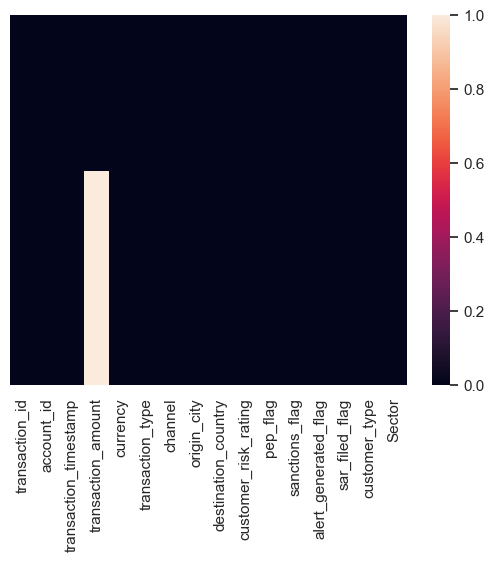

In [9]:
# show the column with missing values
sns.heatmap(data.isnull(), yticklabels=False)

In [3]:
pd.options.display.max_rows = None
data.isnull().sum().sort_values(ascending=False)

transaction_amount       88070
account_id                  80
transaction_type             9
destination_country          5
origin_city                  3
channel                      3
transaction_timestamp        0
transaction_id               0
currency                     0
customer_risk_rating         0
pep_flag                     0
sanctions_flag               0
alert_generated_flag         0
sar_filed_flag               0
customer_type                0
Sector                       0
dtype: int64

In [3]:

num_imputer = SimpleImputer(strategy='median')
data['transaction_amount'] = num_imputer.fit_transform(data[['transaction_amount']])



In [4]:
#data_cleaned=data.dropna(how="all")
data_cleaned=data.dropna()


In [5]:
pd.options.display.max_rows = None
data_cleaned.isnull().sum().sort_values(ascending=False)

transaction_id           0
account_id               0
transaction_timestamp    0
transaction_amount       0
currency                 0
transaction_type         0
channel                  0
origin_city              0
destination_country      0
customer_risk_rating     0
pep_flag                 0
sanctions_flag           0
alert_generated_flag     0
sar_filed_flag           0
customer_type            0
Sector                   0
dtype: int64

In [6]:
#create an instance of label encoder
le = LabelEncoder()

#create an array of columns that you want to encode
cols = ['customer_risk_rating','customer_type','Sector','transaction_type','channel','origin_city']

#encode the column by using fit_transform()

for col in cols:
    data_cleaned[col] = le.fit_transform(data_cleaned[col])


#view the the dataset for labelEncoding
data_cleaned.head(3)

,transaction_id,account_id,transaction_timestamp,transaction_amount,currency,transaction_type,channel,origin_city,destination_country,customer_risk_rating,pep_flag,sanctions_flag,alert_generated_flag,sar_filed_flag,customer_type,Sector
0,TX100000000,5766446.0,18/10/2025 21:17,51091.28,USD,1,4,1,ZW,0,1,1,0,1,0,4
1,TX100000001,251240.0,28/7/2025 15:21,124159.06,USD,3,3,1,ZW,0,0,0,0,0,0,4
2,TX100000002,598902.0,20/10/2025 08:38,62749.52,USD,4,1,2,ZW,0,0,0,0,0,0,3


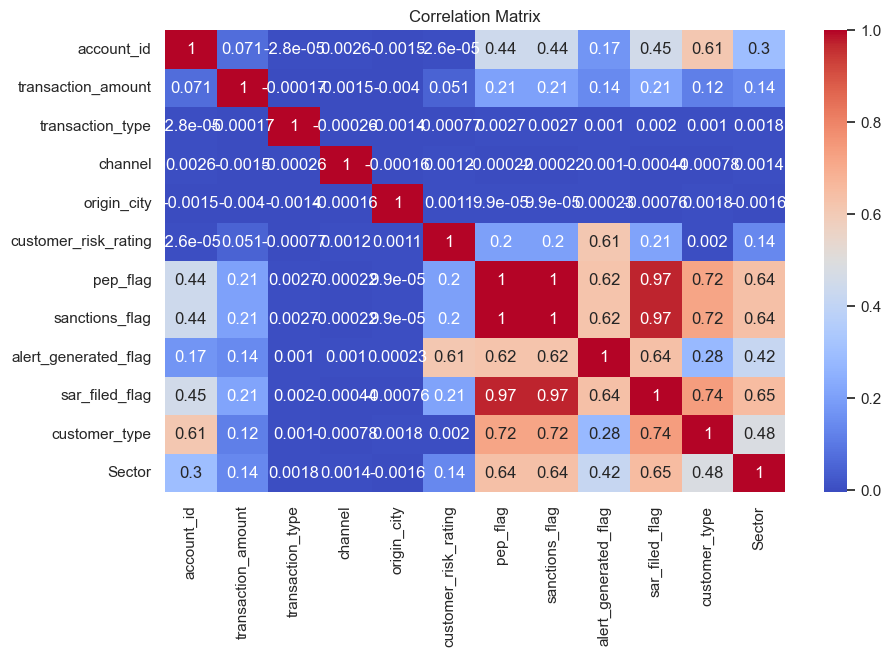

In [14]:
#Visualize the whole dataset on numerical datatype columns

plt.figure(figsize=(10,6))
sns.heatmap(data_cleaned.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()


<Axes: xlabel='sar_filed_flag', ylabel='count'>

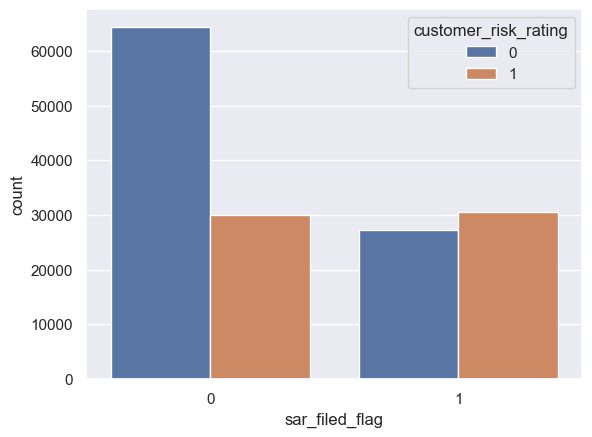

In [16]:
#Show the counts of observations in each categorical bin using bars
sns.countplot(data_cleaned, x='sar_filed_flag', hue="customer_risk_rating")

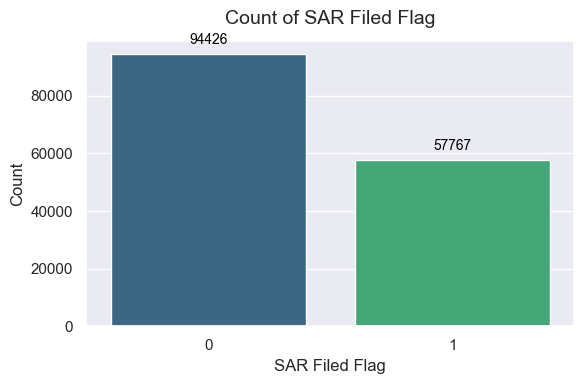

In [9]:
#Show the counts of observations in each categorical bin using bars
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=data_cleaned, x='sar_filed_flag', palette='viridis')

ax.set_title('Count of SAR Filed Flag', fontsize=14, pad=12)
ax.set_xlabel('SAR Filed Flag', fontsize=12)
ax.set_ylabel('Count', fontsize=12)

# add value labels on bars
for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center', va='bottom',
        fontsize=10, color='black',
        xytext=(0, 5), textcoords='offset points'
    )

plt.tight_layout()
plt.show()

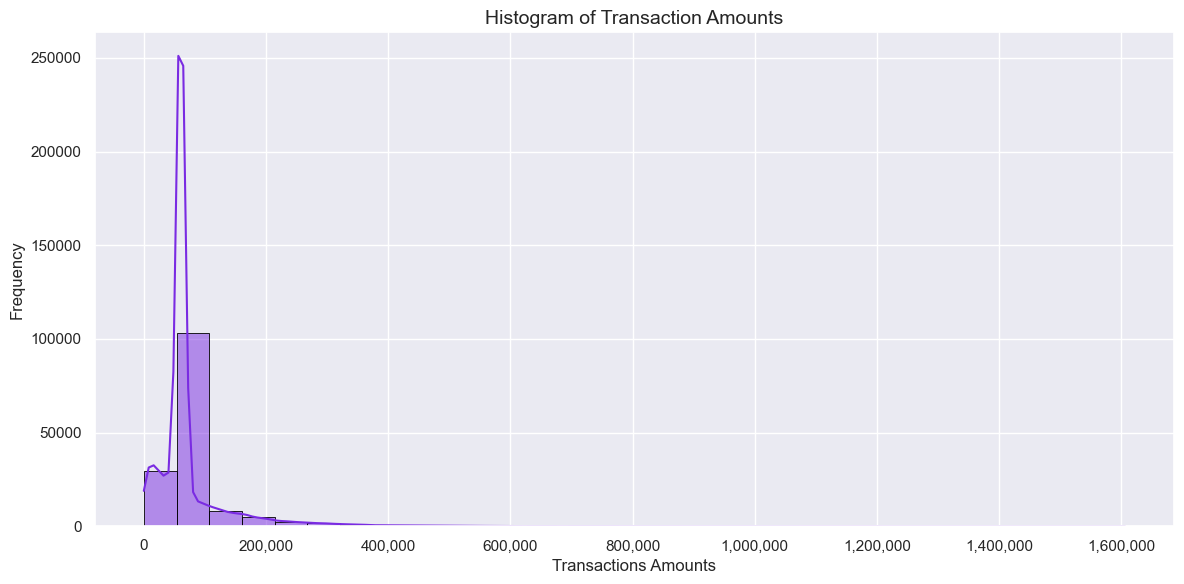

In [13]:

from matplotlib.ticker import FuncFormatter

col = "transaction_amount"  

plt.figure(figsize=(12, 6))
ax = sns.histplot(
    data=data_cleaned,
    x=col,
    bins=30,
    kde=True,
    color="#7A2BE2",
    edgecolor="black",
    linewidth=0.6,
    stat="count"
)

ax.set_title("Histogram of Transaction Amounts", fontsize=14)
ax.set_xlabel("Transactions Amounts", fontsize=12)
ax.set_ylabel("Frequency", fontsize=12)

# Show full numbers on x-axis (no 1e6 / scientific notation)
ax.ticklabel_format(style='plain', axis='x', useOffset=False)

# Optional: add comma separators
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x:,.0f}"))

plt.tight_layout()
plt.show()

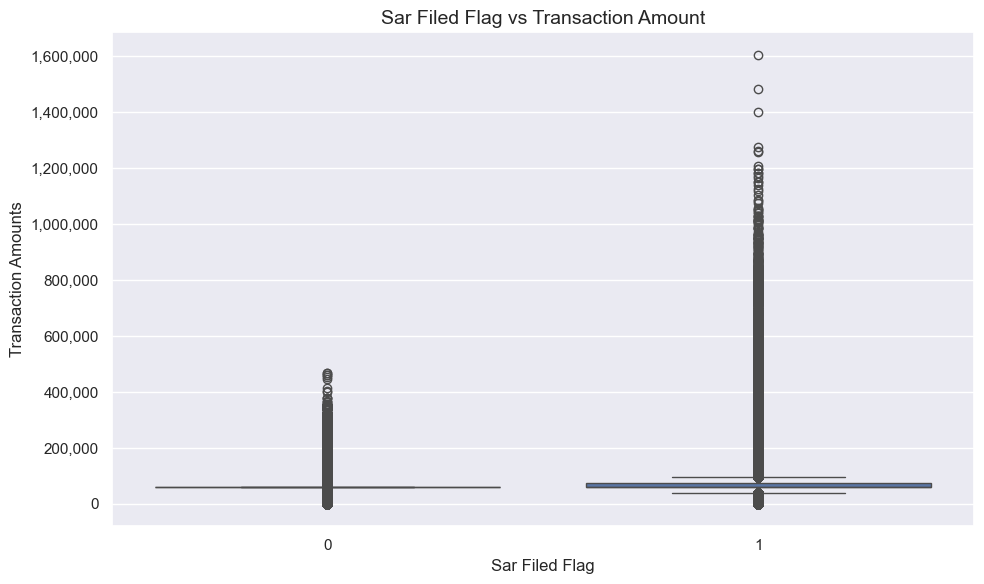

In [20]:


x_col = "sar_filed_flag"
y_col = "transaction_amount"

# ensure dtype is integer (important for palette keys)
data_cleaned[x_col] = data_cleaned[x_col].astype(int)

plt.figure(figsize=(10, 6))
ax = sns.boxplot(
    data=data_cleaned,
    x=x_col,
    y=y_col,)
    

ax.set_title("Sar Filed Flag vs Transaction Amount", fontsize=14)
ax.set_xlabel("Sar Filed Flag", fontsize=12)
ax.set_ylabel("Transaction Amounts", fontsize=12)

ax.yaxis.set_major_formatter(FuncFormatter(lambda v, pos: f"{v:,.0f}"))

plt.tight_layout()
plt.show()

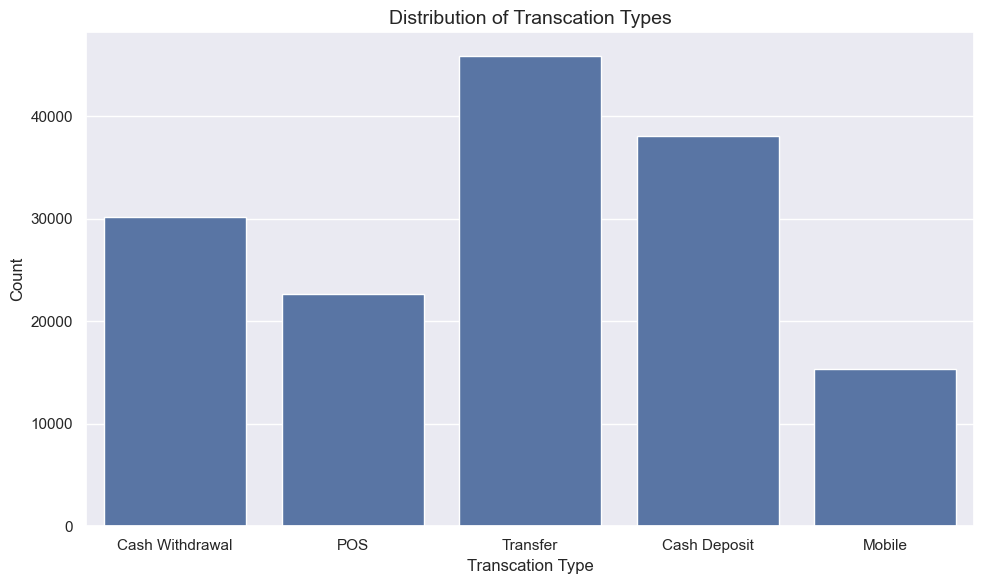

In [22]:
x_col = "transaction_type"  # change to your column name

plt.figure(figsize=(10, 6))
ax = sns.countplot(data=data, x=x_col)

ax.set_title("Distribution of Transcation Types", fontsize=14)
ax.set_xlabel("Transcation Type", fontsize=12)
ax.set_ylabel("Count", fontsize=12)

plt.tight_layout()
plt.show()

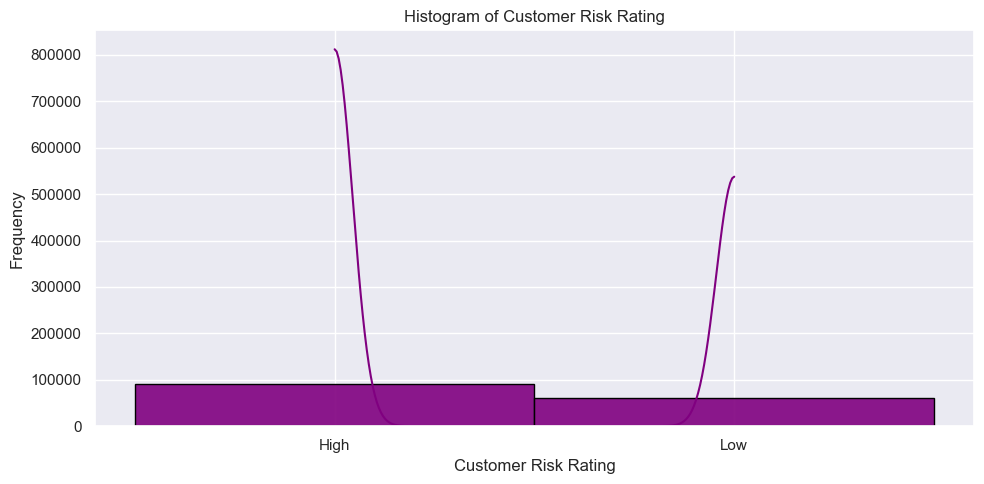

In [43]:


plt.figure(figsize=(10,5))

sns.histplot(
    data=data,
    x="customer_risk_rating",
    bins=20,                # adjust if needed
    kde=True,               # adds the smooth curve
    stat="count",
    color="purple",
    edgecolor="black",
    alpha=0.9
)

plt.title("Histogram of Customer Risk Rating")
plt.xlabel("Customer Risk Rating")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()


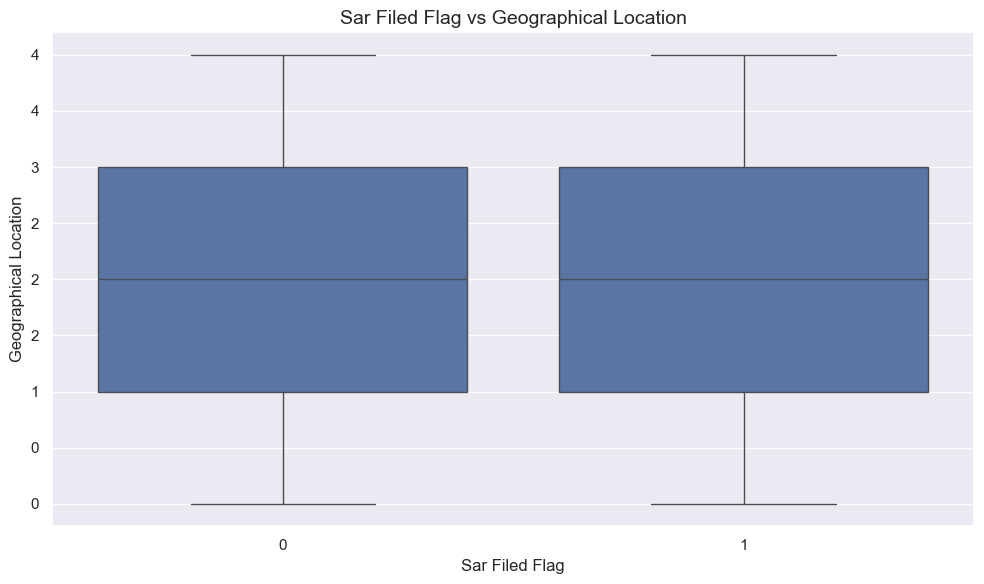

In [48]:
x_col = "sar_filed_flag"
y_col = "origin_city"

# ensure dtype is integer (important for palette keys)
data_cleaned[x_col] = data_cleaned[x_col].astype(int)

plt.figure(figsize=(10, 6))
ax = sns.boxplot(
    data=data_cleaned,
    x=x_col,
    y=y_col,)
    

ax.set_title("Sar Filed Flag vs Geographical Location", fontsize=14)
ax.set_xlabel("Sar Filed Flag", fontsize=12)
ax.set_ylabel("Geographical Location", fontsize=12)

ax.yaxis.set_major_formatter(FuncFormatter(lambda v, pos: f"{v:,.0f}"))

plt.tight_layout()
plt.show()

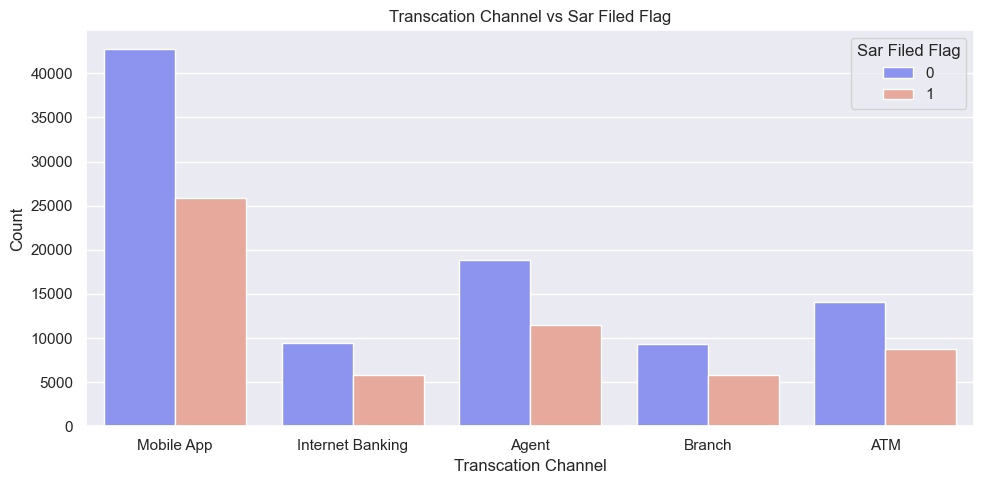

In [35]:




plt.figure(figsize=(10, 5))
ax = sns.countplot(
    data=data_cleaned,
    x="channel",
    hue="sar_filed_flag",
    palette=["#7b86ff", "#f3a18e"]  # similar cool vs orange tones
)

ax.set_title("Transcation Channel vs Sar Filed Flag")
ax.set_xlabel("Transcation Channel")
ax.set_ylabel("Count")

# Put legend title to match the style
legend = ax.legend(title="Sar Filed Flag")
plt.tight_layout()
plt.show()

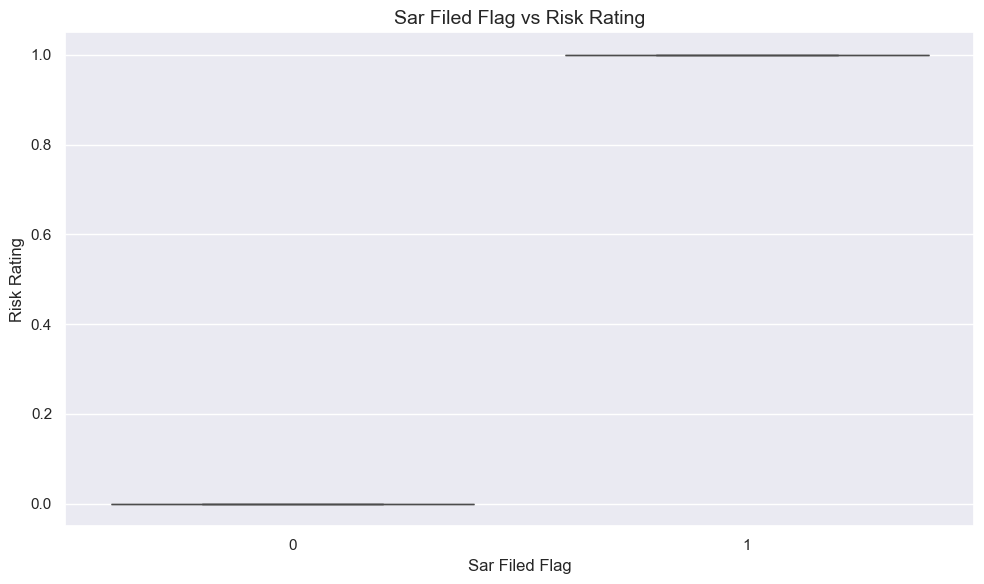

In [40]:

x_col = "sar_filed_flag"
y_col = "customer_risk_rating"

data_cleaned[x_col] = data_cleaned[x_col].astype(int)

plt.figure(figsize=(10, 6))
ax = sns.boxplot(
    data=data_cleaned,
    x=x_col,
    y=y_col,
)

ax.set_title("Sar Filed Flag vs Risk Rating", fontsize=14)
ax.set_xlabel("Sar Filed Flag", fontsize=12)
ax.set_ylabel("Risk Rating", fontsize=12)

plt.tight_layout()
plt.show()


<Axes: ylabel='Frequency'>

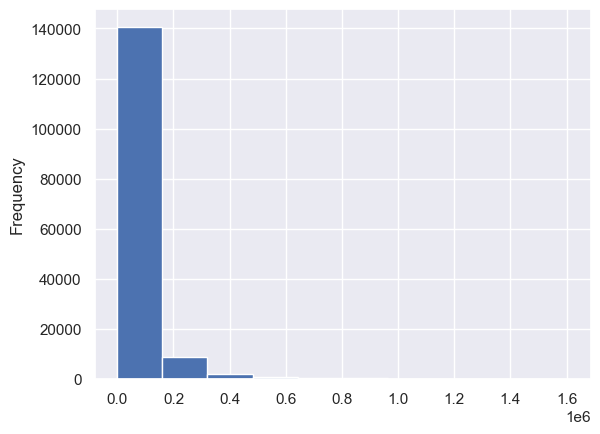

In [ ]:
#explore the amount distribution
data_cleaned['transaction_amount'].plot.hist()

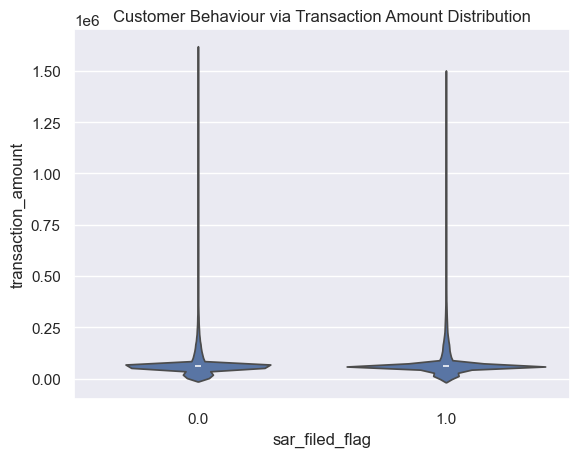

In [50]:

sns.violinplot(x='sar_filed_flag', y='transaction_amount', data=data)

plt.title('Customer Behaviour via Transaction Amount Distribution')
plt.show()


## Drop column which are less important

In [7]:
#These are less important to the model
data_cleaned1 = data_cleaned.drop(['transaction_id','account_id','currency','destination_country'], axis = 1)
data_cleaned1.shape

(152193, 12)

In [8]:
data_cleaned1.head(2)

,transaction_timestamp,transaction_amount,transaction_type,channel,origin_city,customer_risk_rating,pep_flag,sanctions_flag,alert_generated_flag,sar_filed_flag,customer_type,Sector
0,18/10/2025 21:17,51091.28,1,4,1,0,1,1,0,1,0,4
1,28/7/2025 15:21,124159.06,3,3,1,0,0,0,0,0,0,4


In [9]:
# Convert timestamp into useful time features to hour only
data_cleaned1["transaction_timestamp"] = pd.to_datetime(data_cleaned1["transaction_timestamp"])
# Keep only hour
data_cleaned1["hour"] = data_cleaned1["transaction_timestamp"].dt.hour
data_cleaned1=data_cleaned1.drop('transaction_timestamp', axis=1)
data_cleaned1.head(2)


,transaction_amount,transaction_type,channel,origin_city,customer_risk_rating,pep_flag,sanctions_flag,alert_generated_flag,sar_filed_flag,customer_type,Sector,hour
0,51091.28,1,4,1,0,1,1,0,1,0,4,21
1,124159.06,3,3,1,0,0,0,0,0,0,4,15


#The Data set named data_cleaned1 is now cleaned with no missing values

## Part 4 Model Definition

The objective of this model is to detect suspicious transactions, anti money laundering by estimating the likelihood that a transaction will result in the filing of a Suspicious Activity Report (SAR) that is if the rules has been hit, using historical transaction and customer risk data.

Model Type:
Supervised classification model
Algorithm: Random Forest Classifier

Target Variable (Dependent Variable): sar_filed_flag

### Data Preparation - Dependent Variable and Dataset splitting

In [10]:
#remove the target column to created independant features
#The below variables are very much correlated with the target variable and hence will cause data leakage and multicollinearity hence casing the model to be too perfect and overfitt
X_data = data_cleaned1.drop(['sar_filed_flag', 'pep_flag','sanctions_flag','alert_generated_flag'], axis=1)

#create target dataset
y_data = data_cleaned1['sar_filed_flag']

## Training / Test Dataset

In [11]:
# Splitting the dataset into training and testing parts

X_train, X_test, y_train, y_test = train_test_split(X_data, y_data, test_size = 0.2, random_state = 44)

In [12]:
X_train.head(5)

,transaction_amount,transaction_type,channel,origin_city,customer_risk_rating,customer_type,Sector,hour
148541,60446.76,4,4,4,0,1,5,3
10606,36048.82,1,1,4,1,0,3,18
44418,42277.22,1,1,4,0,0,3,23
11193,59395.20,4,2,2,0,0,2,6
111305,60446.76,3,2,2,0,0,2,7


In [21]:
X_train.columns

Index(['transaction_amount', 'transaction_type', 'channel', 'origin_city',
       'customer_risk_rating', 'customer_type', 'Sector', 'hour'],
      dtype='str')

## Feature Scaling

In [13]:
# Doing feature scaling by StandardScaler
sc = StandardScaler()

X_train_scaled = sc.fit_transform(X_train)
X_test_scaled = sc.transform(X_test)

In [14]:
X_train_scaled

array([[-0.19982484,  1.21918843,  1.41270017, ...,  1.57757829,
         1.10058553, -1.22612707],
       [-0.52415072, -0.65830727, -0.70496734, ..., -0.63388296,
         0.0872865 ,  0.93953505],
       [-0.44135556, -0.65830727, -0.70496734, ..., -0.63388296,
         0.0872865 ,  1.66142242],
       ...,
       [-0.19982484,  0.59335653,  1.41270017, ...,  1.57757829,
         1.60723505, -1.22612707],
       [-0.7342633 , -0.03247537, -0.70496734, ...,  1.57757829,
         1.10058553, -0.64861717],
       [-0.00307933, -1.28413917,  0.706811  , ..., -0.63388296,
        -1.43266205, -1.37050455]], shape=(121754, 8))

## Part 5 Model Building

In [15]:
# Building the models

# Model 1: Random Forest
model = RandomForestClassifier(class_weight='balanced', random_state=42)
model.fit(X_train_scaled,y_train)

# Model 2: XGBoost
xgb_model = XGBClassifier(
    n_estimators=50,   
    max_depth=4,
    learning_rate=0.1,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)
xgb_model.fit(X_train_scaled, y_train)
xgb_pred = xgb_model.predict(X_test_scaled)

# Model 3: SVM
svm_model = SVC(kernel='linear', probability=True)
svm_model.fit(X_train_scaled, y_train)
svm_pred = svm_model.predict(X_test_scaled)


In [16]:
#test the model buy usin test data that was not used during training for random forest
y_pred = model.predict(X_test_scaled)

In [20]:

from statsmodels.stats.contingency_tables import mcnemar
import numpy as np

def run_mcnemar(y_true, pred1, pred2, name1, name2):
    
    # Build contingency table
    both_correct = np.sum((pred1 == y_true) & (pred2 == y_true))
    only_1_correct = np.sum((pred1 == y_true) & (pred2 != y_true))
    only_2_correct = np.sum((pred1 != y_true) & (pred2 == y_true))
    both_wrong = np.sum((pred1 != y_true) & (pred2 != y_true))
    
    table = [[both_correct, only_1_correct],
             [only_2_correct, both_wrong]]
    
    print(f"\n{name1} vs {name2}")
    print("Contingency Table:")
    print(np.array(table))
    
    result = mcnemar(table, exact=False, correction=True)
    
    print(f"Statistic: {result.statistic:.4f}")
    print(f"P-value: {result.pvalue:.4f}")
    
    if result.pvalue < 0.05:
        print("✅ Significant difference")
    else:
        print("❌ No significant difference")


In [21]:

# Random Forest vs XGBoost
run_mcnemar(y_test, y_pred, xgb_pred, "Random Forest", "XGBoost")

# Random Forest vs SVM
run_mcnemar(y_test, y_pred, svm_pred, "Random Forest", "SVM")

# XGBoost vs SVM
run_mcnemar(y_test, xgb_pred, svm_pred, "XGBoost", "SVM")



Random Forest vs XGBoost
Contingency Table:
[[27985   223]
 [  622  1609]]
Statistic: 187.4604
P-value: 0.0000
✅ Significant difference

Random Forest vs SVM
Contingency Table:
[[27289   919]
 [  745  1486]]
Statistic: 17.9862
P-value: 0.0000
✅ Significant difference

XGBoost vs SVM
Contingency Table:
[[27668   939]
 [  366  1466]]
Statistic: 250.7157
P-value: 0.0000
✅ Significant difference


In [23]:

from sklearn.metrics import roc_auc_score

def auc_ci(y_true, y_prob, n_bootstrap=1000, alpha=0.95):
    
    rng = np.random.RandomState(42)
    scores = []
    
    for _ in range(n_bootstrap):
        indices = rng.randint(0, len(y_true), len(y_true))
        
        if len(np.unique(y_true[indices])) < 2:
            continue
        
        score = roc_auc_score(y_true[indices], y_prob[indices])
        scores.append(score)
    
    lower = np.percentile(scores, (1 - alpha) / 2 * 100)
    upper = np.percentile(scores, (1 + alpha) / 2 * 100)
    
    print(f"AUC CI ({int(alpha*100)}%): [{lower:.4f}, {upper:.4f}]")
    
    return lower, upper



In [24]:

# RF probabilities
y_prob = model.predict_proba(X_test_scaled)[:, 1]

# XGB probabilities
xgb_prob = xgb_model.predict_proba(X_test_scaled)[:, 1]

# SVM probabilities
svm_prob = svm_model.predict_proba(X_test_scaled)[:, 1]

auc_ci(y_test.values, y_prob)
auc_ci(y_test.values, xgb_prob)
auc_ci(y_test.values, svm_prob)


AUC CI (95%): [0.9706, 0.9740]
AUC CI (95%): [0.9790, 0.9817]
AUC CI (95%): [0.9709, 0.9742]


(np.float64(0.9709328066981057), np.float64(0.9742362044560541))

In [ ]:

plt.figure(figsize=(10, 5))

# Plot bars
plt.bar(x - 1.5*width, accuracy, width, label='Accuracy')
plt.bar(x - 0.5*width, precision, width, label='Precision')
plt.bar(x + 0.5*width, recall, width, label='Recall')
plt.bar(x + 1.5*width, f1_score, width, label='F1 Score')

# Labels and title
plt.xlabel('Model')
plt.ylabel('Score')
plt.title('Comparison of Machine Learning Models')


## Evaluate All Models Considered for accuracy

In [26]:
#Accuracy
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred))
print("XGBoost Accuracy:", accuracy_score(y_test, xgb_pred))
print("SVM Accuracy:", accuracy_score(y_test, svm_pred))


Random Forest Accuracy: 0.9267058707579092
XGBoost Accuracy: 0.9398140543381845
SVM Accuracy: 0.9209895200236539


In [27]:
#Classification Reports
print("\nRandom Forest Report:\n", classification_report(y_test, y_pred))
print("\nXGBoost Report:\n", classification_report(y_test, xgb_pred))
print("\nSVM Report:\n", classification_report(y_test, svm_pred))



Random Forest Report:
               precision    recall  f1-score   support

           0       0.94      0.94      0.94     18908
           1       0.90      0.90      0.90     11531

    accuracy                           0.93     30439
   macro avg       0.92      0.92      0.92     30439
weighted avg       0.93      0.93      0.93     30439


XGBoost Report:
               precision    recall  f1-score   support

           0       0.95      0.96      0.95     18908
           1       0.93      0.91      0.92     11531

    accuracy                           0.94     30439
   macro avg       0.94      0.93      0.94     30439
weighted avg       0.94      0.94      0.94     30439


SVM Report:
               precision    recall  f1-score   support

           0       0.92      0.95      0.94     18908
           1       0.92      0.87      0.89     11531

    accuracy                           0.92     30439
   macro avg       0.92      0.91      0.92     30439
weighted avg      

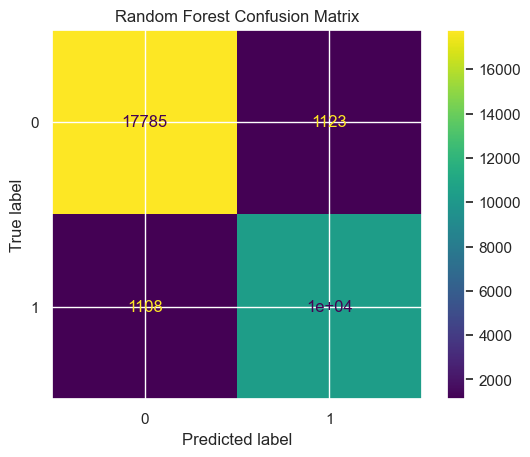

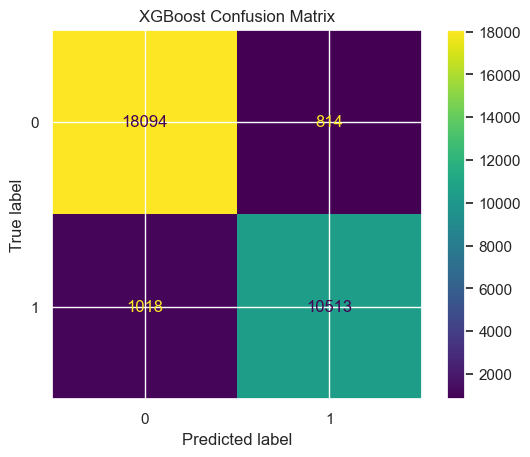

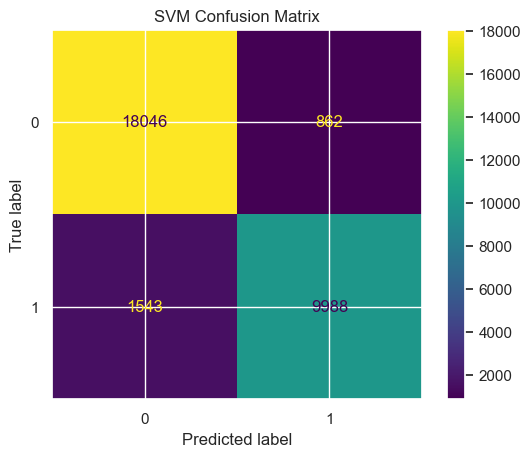

In [28]:

#Confusion Matrices

# Random Forest
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title("Random Forest Confusion Matrix")
plt.show()

# XGBoost
ConfusionMatrixDisplay.from_predictions(y_test, xgb_pred)
plt.title("XGBoost Confusion Matrix")
plt.show()

# SVM
ConfusionMatrixDisplay.from_predictions(y_test, svm_pred)
plt.title("SVM Confusion Matrix")
plt.show()


In [30]:
#Cross Validation
rf_cv = cross_val_score(model, X_train_scaled, y_train, cv=3)
xgb_cv = cross_val_score(xgb_model, X_train_scaled, y_train, cv=2)
svm_cv = cross_val_score(svm_model, X_train_scaled, y_train, cv=2)

print("RF CV Mean:", rf_cv.mean())
print("XGB CV Mean:", xgb_cv.mean())
print("SVM CV Mean:", svm_cv.mean())


RF CV Mean: 0.9281584199422367
XGB CV Mean: 0.9390328038503868
SVM CV Mean: 0.9209060893276606


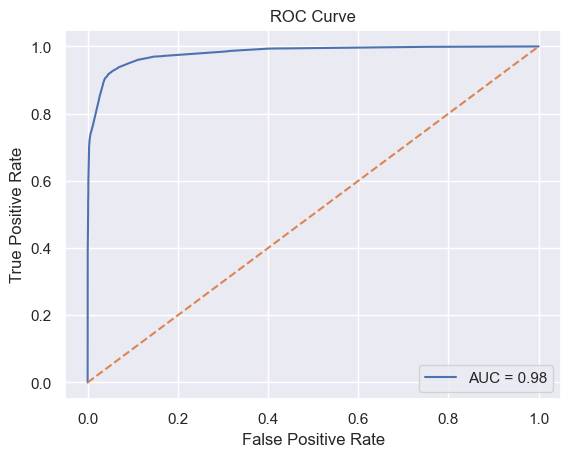

In [19]:

from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

y_prob = xgb_model.predict_proba(X_test_scaled)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


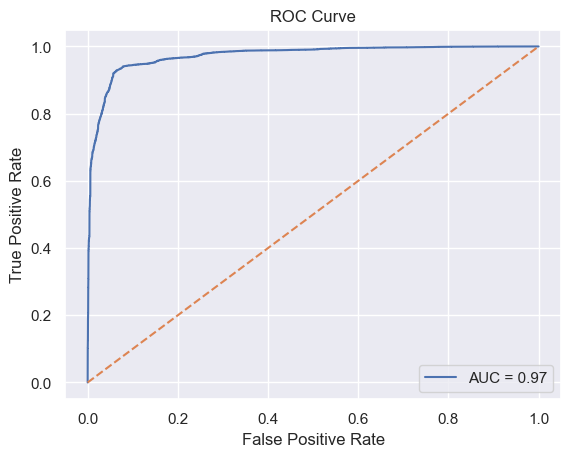

In [25]:

from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

y_prob = svm_model.predict_proba(X_test_scaled)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


Sector                  0.602191
customer_type           0.322922
customer_risk_rating    0.063519
transaction_amount      0.009483
hour                    0.000775
transaction_type        0.000530
origin_city             0.000378
channel                 0.000202
dtype: float32


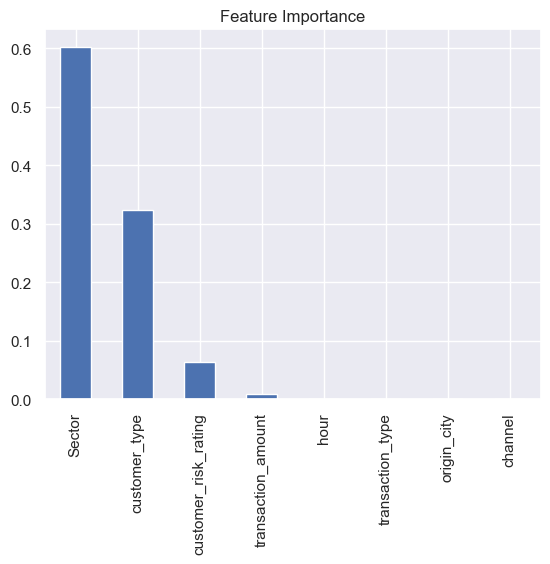

In [21]:
importances = xgb_model.feature_importances_
features = X_data.columns

feat_imp = pd.Series(importances, index=features).sort_values(ascending=False)

print(feat_imp)

feat_imp.plot(kind='bar', title="Feature Importance")
plt.show()

customer_type           1.646009
Sector                  1.134197
customer_risk_rating    0.697812
transaction_amount      0.406815
transaction_type       -0.000028
origin_city            -0.000052
hour                   -0.000108
channel                -0.000146
dtype: float64


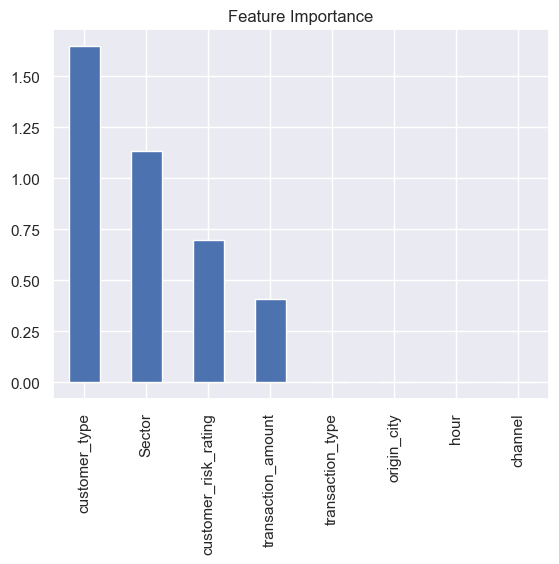

In [ ]:
# ✅ SVM does not have feature impotance so as approcimaxation we correct for linear SVM 
importances = svm_model.coef_[0]   
features = X_data.columns

feat_imp = pd.Series(importances, index=features).sort_values(ascending=False)

print(feat_imp)

feat_imp.plot(kind='bar', title="Feature Importance")
plt.show()


In [31]:

models = {
    "Random Forest": model,
    "XGBoost": xgb_model,
    "SVM": svm_model
}

for name, model in models.items():
    y_pred = model.predict(X_test_scaled)
    print(f"{name} Accuracy:", accuracy_score(y_test, y_pred))


Random Forest Accuracy: 0.9267058707579092
XGBoost Accuracy: 0.9398140543381845
SVM Accuracy: 0.9209895200236539


In [29]:

import time
import pandas as pd

# ✅ Storing my already-trained models
models = {
    "Random Forest": model,
    "XGBoost": xgb_model,
    "SVM": svm_model
}

results = []

for name, mdl in models.items():
    
    # ✅ Measure prediction time only (since already trained)
    start_pred = time.time()
    mdl.predict(X_test_scaled)
    pred_time = time.time() - start_pred
    
    results.append([name, pred_time])

# ✅ Create DataFrame
time_df = pd.DataFrame(results, columns=["Model", "Prediction Time (seconds)"])

# ✅ Sort fastest → slowest
time_df = time_df.sort_values(by="Prediction Time (seconds)")

print(time_df)


           Model  Prediction Time (seconds)
1        XGBoost                   0.008882
0  Random Forest                   0.496090
2            SVM                   5.017524


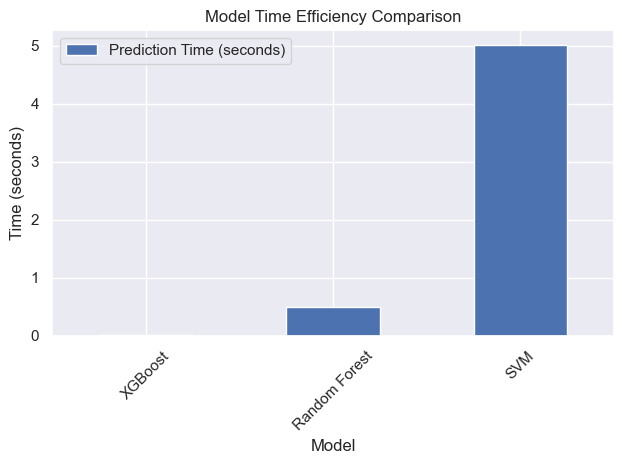

In [30]:

import matplotlib.pyplot as plt

time_df.set_index("Model").plot(kind="bar")

plt.title("Model Time Efficiency Comparison")
plt.ylabel("Time (seconds)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [26]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
# Random Forest
rf_metrics = [
    accuracy_score(y_test, y_pred),
    precision_score(y_test, y_pred),
    recall_score(y_test, y_pred),
    f1_score(y_test, y_pred)
]

# XGBoost
xgb_metrics = [
    accuracy_score(y_test, xgb_pred),
    precision_score(y_test, xgb_pred),
    recall_score(y_test, xgb_pred),
    f1_score(y_test, xgb_pred)
]

# SVM
svm_metrics = [
    accuracy_score(y_test, svm_pred),
    precision_score(y_test, svm_pred),
    recall_score(y_test, svm_pred),
    f1_score(y_test, svm_pred)
]



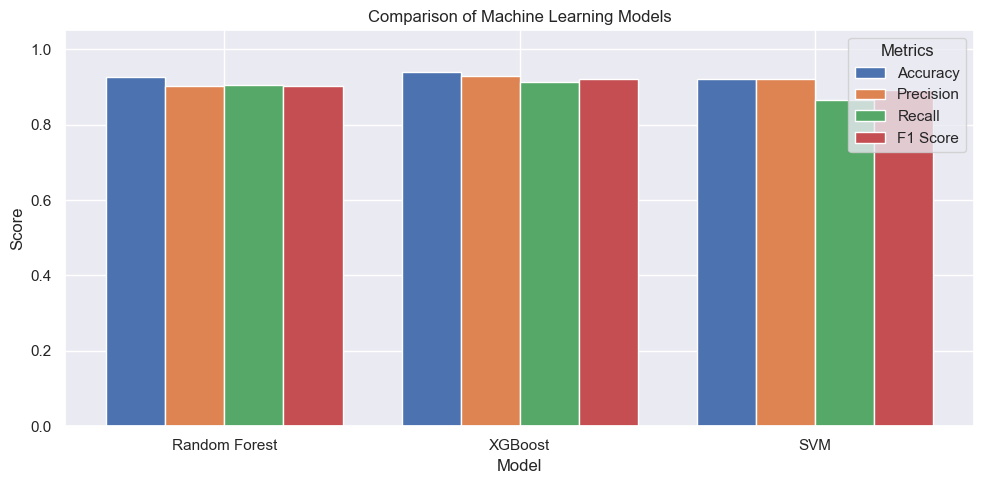

In [27]:



models = ['Random Forest', 'XGBoost', 'SVM']

accuracy = [rf_metrics[0], xgb_metrics[0], svm_metrics[0]]
precision = [rf_metrics[1], xgb_metrics[1], svm_metrics[1]]
recall = [rf_metrics[2], xgb_metrics[2], svm_metrics[2]]
f1 = [rf_metrics[3], xgb_metrics[3], svm_metrics[3]]

x = np.arange(len(models))
width = 0.2

plt.figure(figsize=(10, 5))

plt.bar(x - 1.5*width, accuracy, width, label='Accuracy')
plt.bar(x - 0.5*width, precision, width, label='Precision')
plt.bar(x + 0.5*width, recall, width, label='Recall')
plt.bar(x + 1.5*width, f1, width, label='F1 Score')

plt.xlabel('Model')
plt.ylabel('Score')
plt.title('Comparison of Machine Learning Models')
plt.xticks(x, models)
plt.ylim(0, 1.05)
plt.legend(title='Metrics')

plt.tight_layout()
plt.show()


## Evaluate the Selected Random Forest Model for accuracy

In [32]:
# Evaluating the models' by generating classification report and cross validation scores

aml_prediction_report = classification_report(y_test, y_pred)
print(aml_prediction_report)

              precision    recall  f1-score   support

           0       0.92      0.95      0.94     18908
           1       0.92      0.87      0.89     11531

    accuracy                           0.92     30439
   macro avg       0.92      0.91      0.92     30439
weighted avg       0.92      0.92      0.92     30439



In [33]:
#Validation
aml_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='accuracy')
print(f"Random Forest  Cross-Validation Score: {aml_scores}")

Random Forest  Cross-Validation Score: [0.92016755 0.91905877 0.92316537 0.91946943 0.92246407]


In [34]:
#Checking accurracy
accuracy_score(y_test, y_pred)

0.9209895200236539

In [35]:
#convert the result to percentage
accuracy_score(y_test, y_pred)*100

92.09895200236538

In [36]:
_matrix = confusion_matrix(y_test, y_pred)
_matrix

array([[18046,   862],
       [ 1543,  9988]])

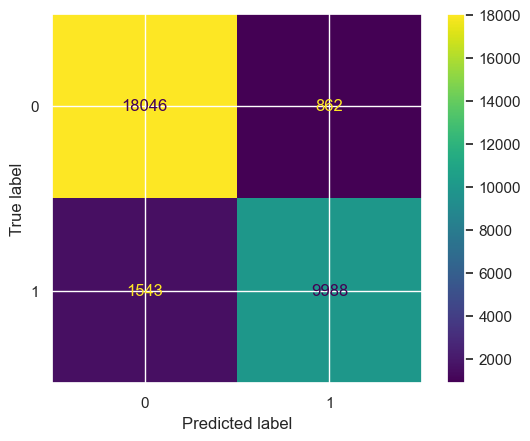

In [37]:
#Confusion matrix heatmap
disp = ConfusionMatrixDisplay(confusion_matrix=_matrix, display_labels=model.classes_)
disp.plot()
plt.show()

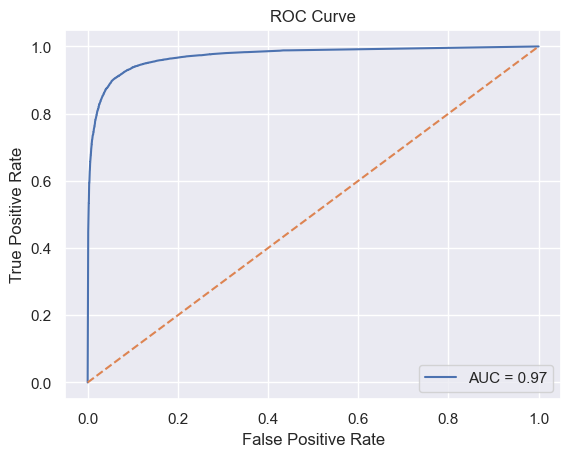

In [34]:

from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

y_prob = model.predict_proba(X_test_scaled)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


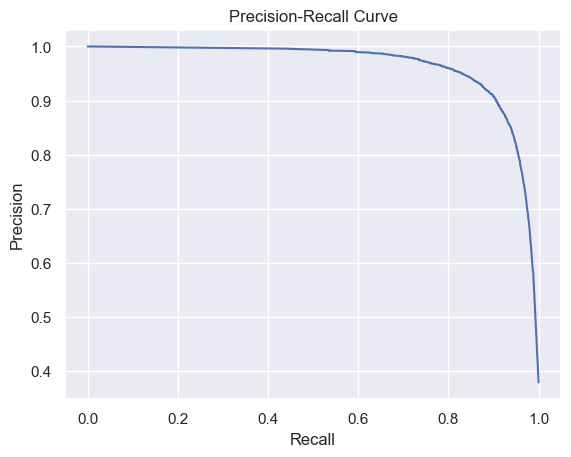

In [35]:

from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()


Sector                  0.381121
customer_type           0.366791
transaction_amount      0.085797
hour                    0.062302
customer_risk_rating    0.047085
channel                 0.019422
origin_city             0.019344
transaction_type        0.018138
dtype: float64


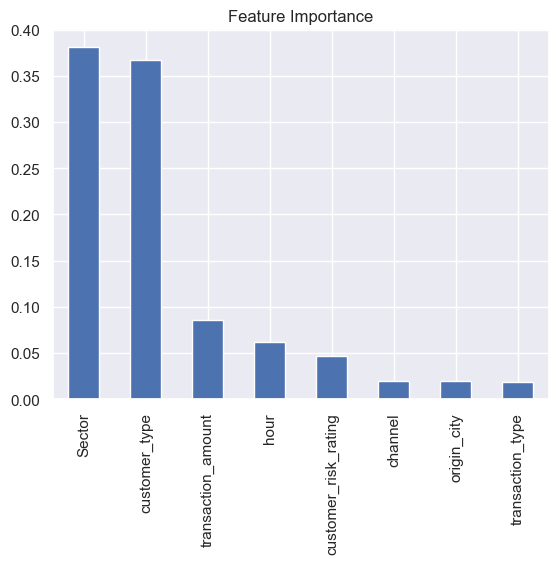

In [36]:

importances = model.feature_importances_
features = X_data.columns

feat_imp = pd.Series(importances, index=features).sort_values(ascending=False)

print(feat_imp)

feat_imp.plot(kind='bar', title="Feature Importance")
plt.show()


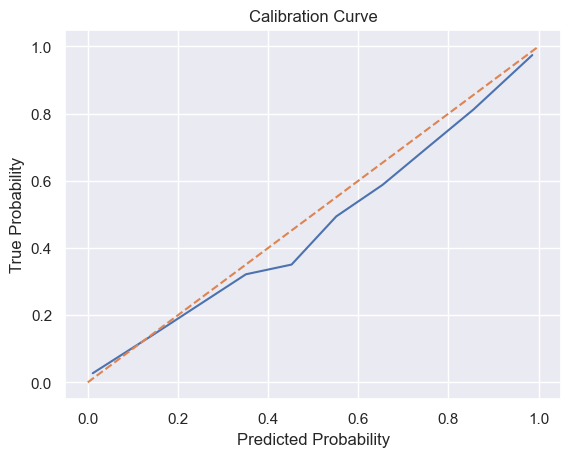

In [37]:

from sklearn.calibration import calibration_curve

prob_true, prob_pred = calibration_curve(y_test, y_prob, n_bins=10)

plt.plot(prob_pred, prob_true)
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("Predicted Probability")
plt.ylabel("True Probability")
plt.title("Calibration Curve")
plt.show()


## Save the Model and Scaler

In [38]:
import joblib

joblib.dump(model, "aml_randomforest_model.pkl")
joblib.dump(sc, "scaler.pkl")


['scaler.pkl']

## Create the Streamlit App File (app.py)

In [ ]:
# Already created app.py in another folder
#streamlit run app.py

SyntaxError: invalid syntax (1252595607.py, line 2)